# 线性回归之正规方程

特征中的缺失值:
0
目标变量中的缺失值: 0

数据集完整，没有缺失值或无穷大值。
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状: (20640, 8)
目标变量形状: (20640,)
[1.03    3.821   1.726   0.934   0.965   2.648   1.573   5.00001 1.398
 3.156  ]
均方误差 (MSE): 0.5559

模型回归系数:
MedInc: 0.8544
HouseAge: 0.1225
AveRooms: -0.2944
AveBedrms: 0.3393
Population: -0.0023
AveOccup: -0.0408
Latitude: -0.8969
Longitude: -0.8698
截距: 2.0719


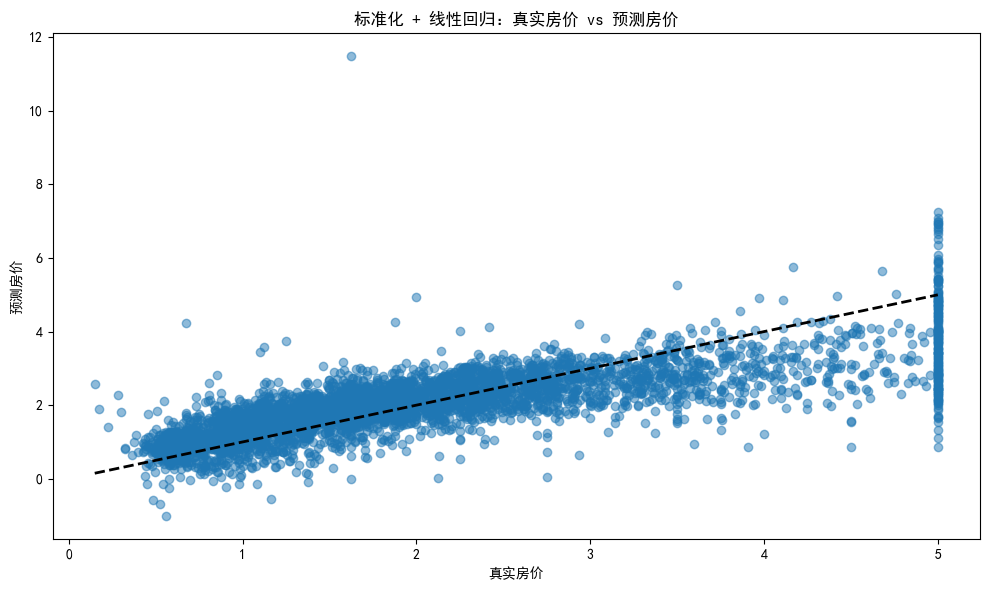

In [8]:
# 线性回归（正规方程/SVD）：加利福尼亚房价预测基线模型

import numpy as np                               # 数值计算库，提供 ndarray 与矩阵运算
import pandas as pd                              # 数据处理库，提供 DataFrame/Series 结构
import matplotlib.pyplot as plt                  # 2D 绘图库，用于可视化预测结果
from sklearn.datasets import fetch_california_housing  # 加载加利福尼亚房价数据集（sklearn 内置）
from sklearn.model_selection import train_test_split   # 将数据集随机划分为训练集和测试集
from sklearn.linear_model import LinearRegression      # 普通最小二乘线性回归；内部使用正规方程或 SVD 求解
from sklearn.metrics import mean_squared_error, r2_score  # MSE：均方误差；R²：决定系数
from sklearn.preprocessing import StandardScaler  # 导入标准化工具

# ── 1. 加载数据集 ─────────────────────────────────────────────────────
housing = fetch_california_housing(data_home='./data')  # 返回 Bunch 对象；data_home 指定本地缓存目录
# Bunch对象是类似字典的对象，常见属性有：
# housing.data: 特征矩阵（ndarray），每行一个样本，每列一个特征
# housing.target: 目标变量（ndarray），即房价中位数
# housing.feature_names: 特征名称（list），如 'MedInc', 'HouseAge' 等
# housing.DESCR: 数据集描述信息（str）
# housing.filename: 本地缓存的文件路径
# housing.frame: 数据表（DataFrame），有些数据集附带此属性（本例不保证一定有）
X = housing.data    # 特征矩阵；类型 ndarray，形状 (20640, 8)
y = housing.target  # 目标变量（房价中位数，单位：10 万美元）；类型 ndarray，形状 (20640,)

# ── 2. 缺失值检查 ────────────────────────────────────────────────────
missing_values = np.isnan(X).sum()            # isnan 返回与 X 同形状布尔矩阵；sum 按列统计 True 个数；返回 ndarray
print('特征中的缺失值:')                        # 打印标题
print(missing_values)                          # 打印各列缺失数，理想情况全为 0

missing_target = np.isnan(y).sum()            # 统计目标列缺失数；返回 int
print(f'目标变量中的缺失值: {missing_target}')  # 打印缺失统计结果

if missing_values.sum() == 0 and missing_target == 0:    # 判断特征和目标均无缺失
    print('\n数据集完整，没有缺失值或无穷大值。')            # 数据完整时打印确认信息
else:                                                      # 存在缺失值则进入此分支
    print('\n数据集存在缺失值或无穷大值，需要进行数据清洗。')  # 提示需要数据清洗

# ── 3. 基本信息打印 ───────────────────────────────────────────────────
print('特征名称:', housing.feature_names)  # list[str]，包含 8 个特征名（MedInc, HouseAge 等）
print('数据集形状:', X.shape)              # 应输出 (20640, 8)；行=样本数，列=特征数
print('目标变量形状:', y.shape)            # 应输出 (20640,)

# ── 4. 划分训练集 / 测试集 ────────────────────────────────────────────
# test_size=0.2 表示 20% 作为测试集；random_state 固定随机种子保证可复现
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 返回 4 个 ndarray
print(y_train[:10])  # 打印前 10 个训练标签，快速确认数据值域

# ── 5. 特征标准化 ───────────────────────────────────────────────
scaler = StandardScaler()                                  # 初始化标准化器
X_train_std = scaler.fit_transform(X_train)                # 用训练集拟合并标准化
X_test_std = scaler.transform(X_test)                      # 用同一参数变换测试集，防止数据泄漏

# ── 6. 初始化并训练模型 ─────────────────────────────────────────
lr_model = LinearRegression()                              # 初始化线性回归；拟合后 coef_ 形状 (8,)，intercept_ 为标量
lr_model.fit(X_train_std, y_train)                         # 在标准化后的特征空间中训练

# ── 7. 预测与误差计算 ─────────────────────────────────────────
y_pred = lr_model.predict(X_test_std)                      # 用标准化后的测试集特征做预测
mse = mean_squared_error(y_test, y_pred)                   # 均方误差 = Σ(y_pred - y_true)² / n
print(f'均方误差 (MSE): {mse:.4f}')                        # 打印 MSE，保留 4 位小数

# ── 8. 打印回归系数 ─────────────────────────────────────────
print('\n模型回归系数:')                                   # 打印标题
for name, coef in zip(housing.feature_names, lr_model.coef_):
    print(f'{name}: {coef:.4f}')                           # 标准化特征下每增加 1 单位，预测房价的变化量
print(f'截距: {lr_model.intercept_:.4f}')                  # 截距项

# ── 9. 可视化：真实值 vs 预测值 ─────────────────────────────
plt.figure(figsize=(10, 6))                                # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']               # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                 # 修正负号显示
plt.scatter(y_test, y_pred, alpha=0.5)                     # 散点图
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # 理想参考线
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('标准化 + 线性回归：真实房价 vs 预测房价')
plt.tight_layout()
plt.show()


## 标准化 + 线性回归 + 模型序列化（joblib 保存/加载）

特征中的缺失值:
0
目标变量中的缺失值: 0

数据集完整，没有缺失值或无穷大值。
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状: (20640, 8)
目标变量形状: (20640,)
[1.03    3.821   1.726   0.934   0.965   2.648   1.573   5.00001 1.398
 3.156  ]
均方误差 (MSE): 0.5559

模型回归系数:
MedInc: 0.8544
HouseAge: 0.1225
AveRooms: -0.2944
AveBedrms: 0.3393
Population: -0.0023
AveOccup: -0.0408
Latitude: -0.8969
Longitude: -0.8698
截距: 2.0719

模型和标准化器已保存


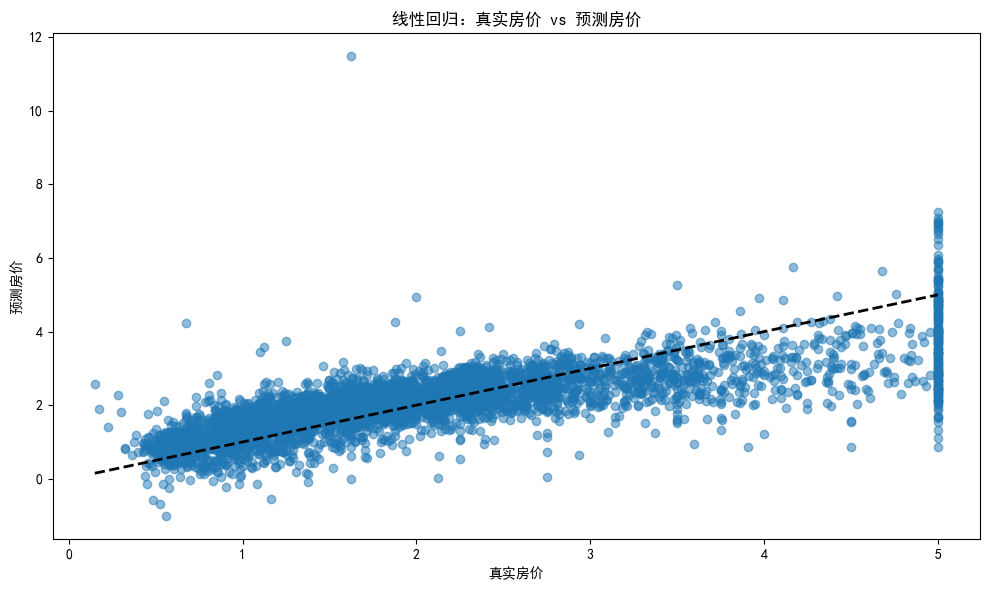

In [9]:
# 标准化 + 线性回归 + 模型序列化（joblib 保存/加载）

import numpy as np                               # 数值计算库
import pandas as pd                              # 数据处理库
import matplotlib.pyplot as plt                  # 绘图库
from sklearn.datasets import fetch_california_housing  # 加载加利福尼亚房价数据集
from sklearn.model_selection import train_test_split   # 数据集划分工具
from sklearn.linear_model import LinearRegression      # 线性回归模型
from sklearn.metrics import mean_squared_error, r2_score  # 均方误差、决定系数
from sklearn.preprocessing import StandardScaler        # 特征标准化：将特征变换为零均值、单位方差
import joblib                                    # sklearn 推荐的模型序列化工具；比 pickle 更高效地处理大型 ndarray

# ── 1. 加载数据 ───────────────────────────────────────────────────────
housing = fetch_california_housing(data_home='./data')  # 返回 Bunch 对象，含 data/target/feature_names
X = housing.data    # 特征矩阵；类型 ndarray，形状 (20640, 8)
y = housing.target  # 目标变量；类型 ndarray，形状 (20640,)

# ── 2. 缺失值检查 ────────────────────────────────────────────────────
missing_values = np.isnan(X).sum()            # 逐列统计特征缺失数；返回 ndarray，长度 8
print('特征中的缺失值:')                        # 打印标题
print(missing_values)                          # 打印各列缺失数

missing_target = np.isnan(y).sum()            # 统计目标列缺失数；返回 int
print(f'目标变量中的缺失值: {missing_target}')  # 打印缺失数

if missing_values.sum() == 0 and missing_target == 0:    # 特征与目标均无缺失
    print('\n数据集完整，没有缺失值或无穷大值。')             # 数据完整时打印确认信息
else:                                                      # 存在缺失值则进入此分支
    print('\n数据集存在缺失值或无穷大值，需要进行数据清洗。')   # 提示需要数据清洗

print('特征名称:', housing.feature_names)  # 8 个特征名列表
print('数据集形状:', X.shape)              # (20640, 8)
print('目标变量形状:', y.shape)            # (20640,)

# ── 3. 划分训练集 / 测试集 ────────────────────────────────────────────
# test_size=0.2：20% 为测试集；random_state=42：固定随机种子保证可复现
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 返回 4 个 ndarray
print(y_train[:10])  # 打印前 10 个训练标签，验证数据值域

# ── 4. 特征标准化（防止数据泄漏）────────────────────────────────────────
scaler = StandardScaler()                      # 初始化标准化器
X_train_scaled = scaler.fit_transform(X_train)  # fit：估计训练集均值/方差；transform：变换到标准正态分布；返回 ndarray
X_test_scaled  = scaler.transform(X_test)       # 仅 transform（用训练集统计量）；严禁在测试集上再次 fit，否则造成数据泄漏

# ── 5. 训练模型 ───────────────────────────────────────────────────────
lr_model = LinearRegression()                  # 初始化线性回归模型
lr_model.fit(X_train_scaled, y_train)          # 在标准化后的训练集上拟合，估计最小二乘解

# ── 6. 预测与评估 ────────────────────────────────────────────────────
y_pred = lr_model.predict(X_test_scaled)       # 对标准化测试集预测；返回 ndarray
mse = mean_squared_error(y_test, y_pred)       # 均方误差；float，越小越好
print(f'均方误差 (MSE): {mse:.4f}')             # 打印 MSE

print('\n模型回归系数:')                                              # 打印标题
for name, coef in zip(housing.feature_names, lr_model.coef_):     # 特征名与系数配对迭代
    print(f'{name}: {coef:.4f}')                                    # 标准化后各系数量纲相同，可直接比较特征重要性
print(f'截距: {lr_model.intercept_:.4f}')  # 截距；标量 float

# ── 7. 模型序列化（保存到磁盘）──────────────────────────────────────────
joblib.dump(lr_model, 'linear_regression_model.pkl')  # 将已拟合的模型序列化为 .pkl 文件
joblib.dump(scaler,   'scaler.pkl')                   # 同时保存 scaler；预测新样本时必须用同一 scaler
print('\n模型和标准化器已保存')                          # 打印保存确认
# ── 8. 可视化 ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))                                    # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']                   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                     # 禁用 unicode 负号
plt.scatter(y_test, y_pred, alpha=0.5)                         # 散点图；点越靠近参考线预测越准
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 理想参考线
plt.xlabel('真实房价')                                          # x 轴标签
plt.ylabel('预测房价')                                          # y 轴标签
plt.title('线性回归：真实房价 vs 预测房价')                      # 图标题
plt.tight_layout()                                             # 自动调整布局
plt.show()                                                     # 渲染图像


## 本地加载模型并预测

In [10]:
# 加载已保存的模型和 Scaler，对新样本与整个测试集进行预测

import joblib                                    # 模型反序列化工具，与保存时使用同一库
from sklearn.datasets import fetch_california_housing  # 重新加载数据（保持与训练时相同的数据源）
from sklearn.model_selection import train_test_split   # 数据集划分

# ── 1. 加载已保存的模型与 Scaler ─────────────────────────────────────────
loaded_scaler = joblib.load('scaler.pkl')                   # 从磁盘反序列化 StandardScaler 对象；返回 StandardScaler
loaded_model  = joblib.load('linear_regression_model.pkl')  # 从磁盘反序列化 LinearRegression 对象
print('模型和标准化器已加载')                                  # 打印加载确认

# ── 2. 重建相同的测试集（必须与训练时使用相同的参数）───────────────────────────
housing = fetch_california_housing(data_home='./data')      # 加载原始数据集
X = housing.data    # 特征矩阵；类型 ndarray，(20640, 8)
y = housing.target  # 目标变量；类型 ndarray，(20640,)

# 必须与保存模型时完全相同的参数，保证测试集内容一致
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 返回 4 个 ndarray

# ── 3. 预测单个新样本 ────────────────────────────────────────────────────
new_house_data = X_test[[-1], :]              # 取测试集最后一行作为新样本；[[-1]] 保持二维形状 (1, 8)
new_house_data_scaled = loaded_scaler.transform(new_house_data)   # 用训练时的 scaler 标准化新样本；不能重新 fit
predicted_price = loaded_model.predict(new_house_data_scaled)     # 预测单个样本；返回长度为 1 的 ndarray
print(f'预测的房价: {predicted_price[0]:.2f}')  # 取第 0 个元素；单位为 10 万美元
print('-' * 100)                               # 打印分隔线

# ── 4. 预测整个测试集并评估 ──────────────────────────────────────────────
X_test_scaled = loaded_scaler.transform(X_test)    # 标准化整个测试集；返回 ndarray
y_pred = loaded_model.predict(X_test_scaled)        # 预测整个测试集；返回 ndarray，长度=len(y_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # 导入多个评估指标

mse = mean_squared_error(y_test, y_pred)   # 均方误差（Mean Squared Error）；float，越小越好
print('\n模型评估指标:')                    # 打印标题
print(f'均方误差 (MSE): {mse:.4f}')         # MSE 越小表示整体预测误差越小




模型和标准化器已加载
预测的房价: 2.01
----------------------------------------------------------------------------------------------------

模型评估指标:
均方误差 (MSE): 0.5559


# 线性回归之梯度下降

### 实战线性回归之梯度下降

特征中的缺失值:
0
目标变量中的缺失值: 0

数据集完整，没有缺失值或无穷大值。
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
数据集形状: (20640, 8)
目标变量形状: (20640,)
[1.03    3.821   1.726   0.934   0.965   2.648   1.573   5.00001 1.398
 3.156  ]
均方误差 (MSE): 0.5506

模型回归系数:
MedInc: 0.8126
HouseAge: 0.1148
AveRooms: -0.2503
AveBedrms: 0.3024
Population: 0.0023
AveOccup: -0.1365
Latitude: -0.9093
Longitude: -0.8906
截距: 2.0573

模型和标准化器已保存


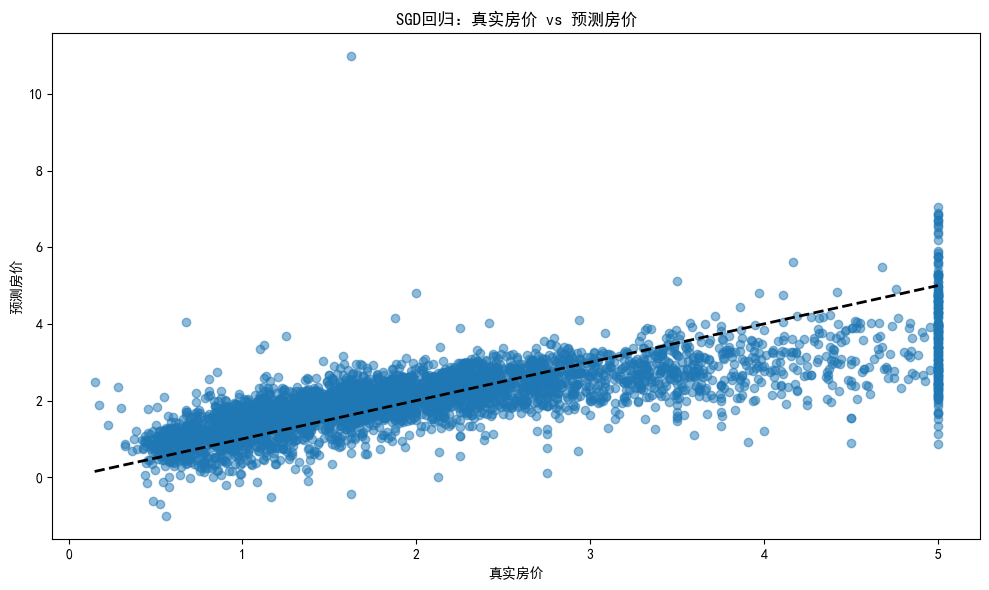

In [11]:
# SGDRegressor：随机梯度下降求解线性回归（适合大规模数据，逐样本/小批量更新参数）

import numpy as np                              # 数值计算
import pandas as pd                             # 数据处理
import matplotlib.pyplot as plt                 # 绘图
from sklearn.datasets import fetch_california_housing  # 加载数据集
from sklearn.model_selection import train_test_split   # 数据集划分
from sklearn.linear_model import SGDRegressor          # 随机梯度下降回归器；支持在线/小批量学习
from sklearn.metrics import mean_squared_error, r2_score  # 评估指标
from sklearn.preprocessing import StandardScaler        # SGD 对特征尺度高度敏感，必须先标准化
import joblib                                    # 模型序列化工具

# ── 1. 加载数据 ───────────────────────────────────────────────────────
housing = fetch_california_housing(data_home='./data')  # 加载数据；返回 Bunch 对象
X = housing.data    # 特征矩阵；类型 ndarray，(20640, 8)
y = housing.target  # 目标变量；类型 ndarray，(20640,)

# ── 2. 缺失值检查 ────────────────────────────────────────────────────
missing_values = np.isnan(X).sum()            # 逐列统计特征缺失数；返回 ndarray
print('特征中的缺失值:')                        # 打印标题
print(missing_values)                          # 打印各列缺失数

missing_target = np.isnan(y).sum()            # 统计目标缺失数；返回 int
print(f'目标变量中的缺失值: {missing_target}')  # 打印缺失数

if missing_values.sum() == 0 and missing_target == 0:    # 判断数据完整性
    print('\n数据集完整，没有缺失值或无穷大值。')             # 数据完整时打印确认
else:                                                      # 存在缺失值则进入此分支
    print('\n数据集存在缺失值或无穷大值，需要进行数据清洗。')   # 提示需要数据清洗

print('特征名称:', housing.feature_names)  # 8 个特征名
print('数据集形状:', X.shape)              # (20640, 8)
print('目标变量形状:', y.shape)            # (20640,)

# ── 3. 划分训练集 / 测试集 ────────────────────────────────────────────
# test_size=0.2：20% 为测试集；random_state=42：固定随机种子
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 返回 4 个 ndarray
print(y_train[:10])  # 打印前 10 个训练标签

# ── 4. 特征标准化 ─────────────────────────────────────────────────────
scaler = StandardScaler()                       # 初始化标准化器
X_train_scaled = scaler.fit_transform(X_train)  # fit：估计均值/方差；transform：标准化；返回 ndarray
X_test_scaled  = scaler.transform(X_test)       # 用训练集统计量变换测试集，防止数据泄漏

# ── 5. 初始化并训练 SGD 回归器 ─────────────────────────────────────────
# max_iter：最大 epoch 数（遍历训练集的次数）
# tol：相邻 epoch 损失变化 < tol 时提前停止
# learning_rate：学习率调度策略（'invscaling'-每轮自动衰减，'constant'-恒定不变，'optimal'-LIBLINEAR建议信策略等）
# eta0：初始学习率（仅在 learning_rate 为 'constant'、'invscaling'、'adaptive' 时有效）
# penalty：正则化方式（'l2'、'l1'、'elasticnet'），防止过拟合
# alpha：正则化系数，控制正则惩罚项强度（默认 0.0001）
# shuffle：每轮是否洗牌训练数据（提升训练效果）
# random_state：随机种子，保证结果可复现
# early_stopping：是否使用提前停止，防止训练过度
# validation_fraction：提前停止时用于验证的训练集比例
sgd_model = SGDRegressor(
    max_iter=1000,            # 最大迭代次数
    tol=1e-3,                 # 提前停止容忍度
    learning_rate='invscaling', # 学习率调度策略（SGD默认，建议配合eta0调整）
    eta0=0.01,                # 初始学习率
    penalty='l2',             # L2正则化
    alpha=0.0001,             # 正则化强度
    shuffle=True,             # 每轮洗牌
    random_state=42           # 随机种子
    # early_stopping=False,   # 如需提前停止，设置为True
    # validation_fraction=0.1 # 提前停止用的验证集比例
)  # 初始化 SGD 回归器，常用参数如上所述
sgd_model.fit(X_train_scaled, y_train)           # 多 epoch 遍历训练集；每次随机取一个样本更新参数

# ── 6. 预测与评估 ─────────────────────────────────────────────────────
y_pred = sgd_model.predict(X_test_scaled)        # 预测测试集；返回 ndarray
mse = mean_squared_error(y_test, y_pred)         # 均方误差；float
print(f'均方误差 (MSE): {mse:.4f}')               # 打印 MSE

print('\n模型回归系数:')                                               # 打印标题
for name, coef in zip(housing.feature_names, sgd_model.coef_):     # 遍历特征名与系数对
    print(f'{name}: {coef:.4f}')                                    # 打印每个特征的回归系数
print(f'截距: {sgd_model.intercept_[0]:.4f}')  # SGDRegressor.intercept_ 是一维数组，取第 0 个元素

# ── 7. 模型序列化 ─────────────────────────────────────────────────────
joblib.dump(sgd_model, 'sgd_regression_model.pkl')  # 保存 SGD 模型
joblib.dump(scaler, 'scaler.pkl')                   # 保存标准化器
print('\n模型和标准化器已保存')                        # 打印保存确认

# ── 8. 可视化 ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))                                    # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']                   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                     # 禁用 unicode 负号
plt.scatter(y_test, y_pred, alpha=0.5)                         # 散点图；横轴真实值，纵轴预测值
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 理想参考线
plt.xlabel('真实房价')                                          # x 轴标签
plt.ylabel('预测房价')                                          # y 轴标签
plt.title('SGD回归：真实房价 vs 预测房价')                       # 图标题
plt.tight_layout()                                             # 自动调整布局
plt.show()                                                     # 渲染图像


# 实战Lasso回归，岭回归

Lasso回归
均方误差 (MSE): 0.5483

Lasso回归系数:
MedInc: 0.8010
HouseAge: 0.1271
AveRooms: -0.1628
AveBedrms: 0.2062
Population: -0.0000
AveOccup: -0.0306
Latitude: -0.7901
Longitude: -0.7557
截距: 2.0719


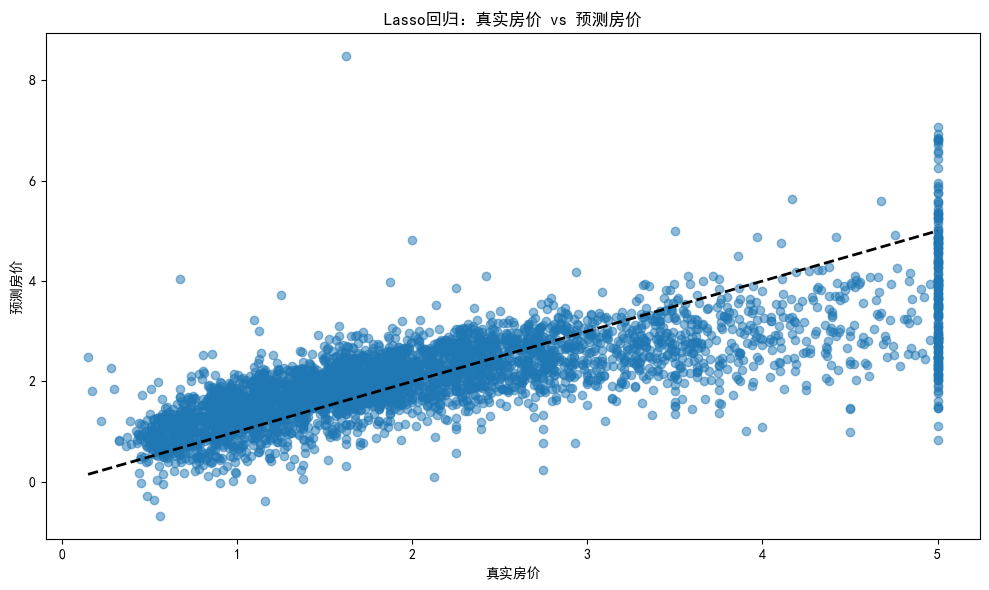


岭回归
均方误差 (MSE): 0.5559

岭回归系数:
MedInc: 0.8543
HouseAge: 0.1226
AveRooms: -0.2942
AveBedrms: 0.3390
Population: -0.0023
AveOccup: -0.0408
Latitude: -0.8962
Longitude: -0.8691
截距: 2.0719


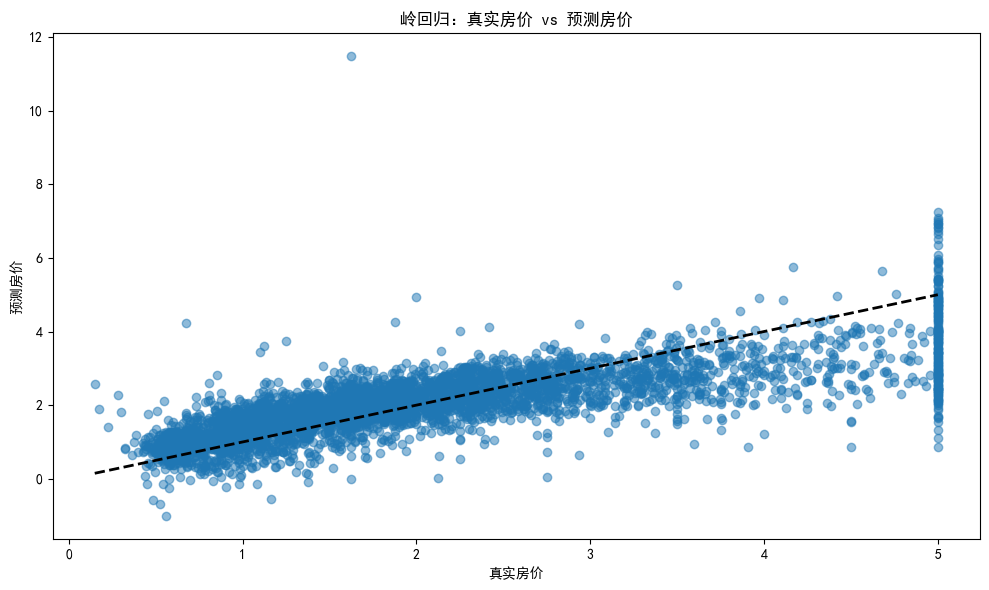

In [12]:
# Lasso（L1 正则）与 Ridge（L2 正则）回归：正则化防止过拟合

from sklearn.linear_model import Lasso, Ridge    # Lasso：L1 正则使系数稀疏化；Ridge：L2 正则使系数整体缩小
from sklearn.metrics import mean_squared_error, r2_score  # 评估指标
from sklearn.model_selection import GridSearchCV  # 超参数网格搜索（可扩展使用）
import numpy as np                               # 数值计算
import matplotlib.pyplot as plt                  # 绘图

# ── 1. Lasso 回归（L1 正则化） ─────────────────────────────────────────
print('=' * 50)    # 打印分隔线
print('Lasso回归')  # 打印标题
print('=' * 50)    # 打印分隔线

# L1 损失 = MSE + alpha * Σ|w_i|；alpha 越大，系数被压缩越厉害；部分系数会精确变为 0（自动特征选择）
# Lasso回归常用超参数说明：
# alpha：正则化强度（默认1.0），越大系数压缩越狠，部分系数变0；建议用交叉验证调优
# max_iter：最大迭代次数（默认1000），数据量大或收敛慢时应适当增大
# tol：收敛判据的阈值，影响精度和运行速度（默认1e-4）
# random_state：随机种子，保证结果可复现
# selection：特征选择的更新方式，'cyclic'或'random'，影响效率
lasso_model = Lasso(alpha=0.01, random_state=42, max_iter=10000)  # alpha=0.01：正则化强度；max_iter增大确保收敛

lasso_model.fit(X_train_scaled, y_train)          # 在标准化训练集上拟合；依赖上一 cell 的 X_train_scaled 等变量
lasso_pred = lasso_model.predict(X_test_scaled)   # 预测测试集；返回 ndarray
lasso_mse = mean_squared_error(y_test, lasso_pred)  # 计算 Lasso 的均方误差；float
print(f'均方误差 (MSE): {lasso_mse:.4f}')           # 打印 Lasso MSE

print('\nLasso回归系数:')                                              # 打印标题
for name, coef in zip(housing.feature_names, lasso_model.coef_):   # 遍历特征名与系数
    print(f'{name}: {coef:.4f}')                                     # L1 正则下部分系数可能精确为 0
print(f'截距: {lasso_model.intercept_:.4f}')  # 截距；标量 float

plt.figure(figsize=(10, 6))                                    # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']                   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                     # 禁用 unicode 负号
plt.scatter(y_test, lasso_pred, alpha=0.5)                     # 散点图
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 参考线
plt.xlabel('真实房价')                                          # x 轴标签
plt.ylabel('预测房价')                                          # y 轴标签
plt.title('Lasso回归：真实房价 vs 预测房价')                     # 图标题
plt.tight_layout()                                             # 自动调整布局
plt.show()                                                     # 渲染图像

# ── 2. Ridge 岭回归（L2 正则化） ────────────────────────────────────────
print('\n' + '=' * 50)   # 打印分隔线
print('岭回归')            # 打印标题
print('=' * 50)            # 打印分隔线

# L2 损失 = MSE + alpha * Σw_i²；系数会整体缩小但不会精确变为 0
# Ridge 回归常用超参数说明：
# alpha：正则化强度（默认1.0），越大系数收缩越明显，防止过拟合；建议用交叉验证调优
# fit_intercept：是否计算截距项（默认True），一般保留默认即可
# normalize：是否标准化特征（在0.24版后已弃用；建议使用外部StandardScaler处理）
# max_iter：最大迭代次数（默认None，迭代器自动确定），数据量大或收敛慢时可增大
# tol：收敛判据阈值（默认1e-3），精度和速度权衡
# solver：优化算法（默认’auto’，可选’svd’/’cholesky’/’lsqr’/’sag’等，影响效率和收敛）
# random_state：随机数种子，仅部分solver有效，保证结果可复现
ridge_model = Ridge(alpha=1.0, random_state=42)   # alpha=1.0：正则化系数；越大系数整体越小

ridge_model.fit(X_train_scaled, y_train)           # 拟合岭回归模型
ridge_pred = ridge_model.predict(X_test_scaled)    # 预测测试集；返回 ndarray
ridge_mse = mean_squared_error(y_test, ridge_pred)  # 计算 Ridge 的均方误差；float
print(f'均方误差 (MSE): {ridge_mse:.4f}')            # 打印 Ridge MSE

print('\n岭回归系数:')                                              # 打印标题
for name, coef in zip(housing.feature_names, ridge_model.coef_):  # 遍历特征名与系数
    print(f'{name}: {coef:.4f}')                                    # L2 正则下系数均收缩但不为 0
print(f'截距: {ridge_model.intercept_:.4f}')  # 截距；标量 float

plt.figure(figsize=(10, 6))                                    # 创建图窗
plt.rcParams['font.sans-serif'] = ['SimHei']                   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                     # 禁用 unicode 负号
plt.scatter(y_test, ridge_pred, alpha=0.5)                     # 散点图
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # y=x 参考线
plt.xlabel('真实房价')                                          # x 轴标签
plt.ylabel('预测房价')                                          # y 轴标签
plt.title('岭回归：真实房价 vs 预测房价')                        # 图标题
plt.tight_layout()                                             # 自动调整布局
plt.show()                                                     # 渲染图像


# 逻辑回归

## 乳腺癌数据集：数据清洗 + 逻辑回归二分类实战


每列缺失值数量:
0      0
1      0
2      0
3      0
4      0
5      0
6     16
7      0
8      0
9      0
10     0
dtype: int64

数据基本信息:
<class 'pandas.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       699 non-null    int64
 1   1       699 non-null    int64
 2   2       699 non-null    int64
 3   3       699 non-null    int64
 4   4       699 non-null    int64
 5   5       699 non-null    int64
 6   6       683 non-null    str  
 7   7       699 non-null    int64
 8   8       699 non-null    int64
 9   9       699 non-null    int64
 10  10      699 non-null    int64
dtypes: int64(10), str(1)
memory usage: 60.2 KB
None

删除缺失值后的数据形状: (683, 11)

数据的基本统计信息:
                 ID  Clump Thickness  Uniformity of Cell Size  \
count  6.830000e+02       683.000000               683.000000   
mean   1.076720e+06         4.442167                 3.150805   
std    6.206440e+05         2.820761

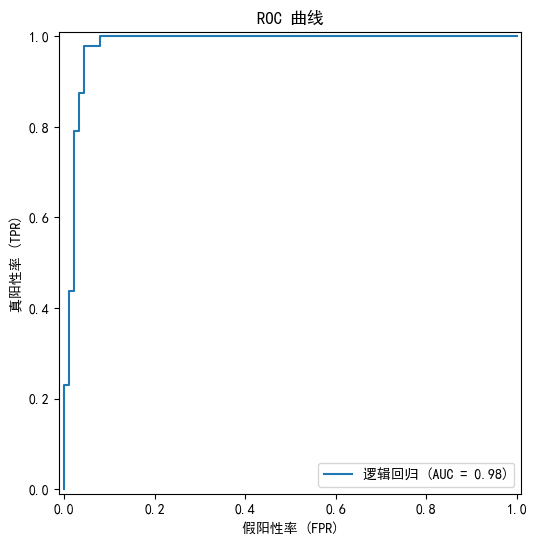


模型评估:
准确率: 0.9635
前5条预测标签： [2 2 2 2 2]

回归系数（coef_）：
[[-0.02869699  0.423231    0.2036803   0.09993954 -0.27713056  0.40062564
  -0.2085514   0.21487608 -0.03697487]]

截距（intercept_）：
[-2.62710038]

测试集上样本的分类概率预测表


,良性,恶性
0,0.892183,0.107817
1,0.930068,0.069932
2,0.836835,0.163165
3,0.931911,0.068089
4,0.897581,0.102419
...,...,...
132,0.031022,0.968978
133,0.879154,0.120846
134,0.676194,0.323806
135,0.915226,0.084774


In [13]:
# 威斯康星乳腺癌数据集：数据清洗 → 逻辑回归二分类（良性=2 / 恶性=4）

import pandas as pd   # 数据处理
import numpy as np    # 数值计算

# ── 1. 读取数据并处理缺失值 ───────────────────────────────────────────────
df = pd.read_csv('data/breast-cancer-wisconsin.csv', header=None)  # header=None 的作用是告诉 read_csv 不将文件的第一行当作列名，而是全部作为数据读取。适用于原文件不含列名或首行即为数据的情况。

df = df.replace('?', np.nan)  # 原始数据用 '?' 表示缺失；替换为 np.nan 使 pandas 识别为缺失值

print('\n每列缺失值数量:')      # 打印标题
print(df.isna().sum())          # isna 返回布尔 DataFrame；sum 统计每列 True 个数；返回 Series

print('\n数据基本信息:')        # 打印标题
print(df.info())                # 打印每列的数据类型、非空计数等信息；返回 None（结果直接打印到控制台）

df_clean = df.dropna()          # 删除含任意缺失的行；返回新 DataFrame，不修改原 df
print(f'\n删除缺失值后的数据形状: {df_clean.shape}')  # 打印清洗后的 (行数, 列数)

# ── 2. 添加具有医学意义的列名 ────────────────────────────────────────────
columns = [                           # 定义 11 个列名的列表
    'ID',                             # 样本 ID（无特征意义，后续删除）
    'Clump Thickness',                # 细胞团厚度（1-10）
    'Uniformity of Cell Size',        # 细胞大小均匀性（1-10）
    'Uniformity of Cell Shape',       # 细胞形状均匀性（1-10）
    'Marginal Adhesion',              # 边缘粘附性（1-10）
    'Single Epithelial Cell Size',    # 单层上皮细胞大小（1-10）
    'Bare Nuclei',                    # 裸核（1-10）
    'Bland Chromatin',                # 温和染色质（1-10）
    'Normal Nucleoli',                # 正常核仁（1-10）
    'Mitoses',                        # 有丝分裂（1-10）
    'Class'                           # 类别标签：2=良性，4=恶性
]                                     # 共 11 列
df_clean.columns = columns  # 将列名赋给 DataFrame；原来是 0~10 的整数索引

# ── 3. 基本统计信息 ──────────────────────────────────────────────────────
print('\n数据的基本统计信息:')                # 打印标题
print(df_clean.describe())                   # 打印各数值列的 count/mean/std/min/25%/50%/75%/max

print('\n类别分布:')                          # 打印标题
print(df_clean['Class'].value_counts())       # 打印各类别样本数；返回 Series（索引=类别值，值=计数）

# ── 4. 构建特征矩阵与标签 ──────────────────────────────────────────────────
X = df_clean.drop(['ID', 'Class'], axis=1)   # 删除 ID（无意义）和标签列；axis=1 按列删除；返回 9 列 DataFrame
y = df_clean['Class']                         # 标签列；类型 Series，值为 2（良性）或 4（恶性）

# ── 5. 划分训练集 / 测试集 ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split  # 导入划分工具

# test_size=0.2：20% 为测试集；random_state=42：固定随机种子保证可复现；stratify=y 添加分层抽样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  

print(f'\n训练集大小: {X_train.shape}')   # 打印训练集 (行数, 列数)
print(f'测试集大小: {X_test.shape}')      # 打印测试集 (行数, 列数)

# ── 6. 初始化并训练逻辑回归模型 ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression                                         # 逻辑回归分类器
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay  # 评估工具：ROC曲线计算、AUC、可视化展示等

# LogisticRegression常用超参数说明：
# C: 正则化项系数的倒数；C 越小正则越强，C 越大模型越趋近无正则；默认 1.0
# penalty: 已在 sklearn 1.8 中弃用，将于 1.10 删除；正则类型改由 l1_ratio 控制（见下方）
# l1_ratio: 正则类型控制参数（仅当 solver='saga' 时有效）；
#           l1_ratio=0   → 纯 L2 正则（等价于旧 penalty='l2'）
#           l1_ratio=1   → 纯 L1 正则（等价于旧 penalty='l1'）
#           0 < l1_ratio < 1 → Elastic Net（旧需显式设置 penalty='elasticnet'）
#           不传此参数时 solver 默认使用 L2
# solver: 优化算法；'liblinear' 适合小数据集且支持 L1/L2；'lbfgs' 适合大多数情况但只支持 L2；'saga' 支持 L1/L2/Elastic Net 且适合大数据
# max_iter: 最大迭代次数；默认 100；数据量大或收敛慢时建议调大，不收敛会抛出 ConvergenceWarning
# tol: 收敛阙值；默认 1e-4；设定越小拟合越精细，但训练时间变长
# random_state: 随机种子，整型；固定后可保证实验结果可复现
model = LogisticRegression(
    C=0.1,                # 正则化强度的倒数；C 越小正则越强，C 越大模型越趋近无正则（默认1.0）
    solver='liblinear',   # 优化算法：适合小数据集，支持 L1/L2 正则，不支持 elasticnet
    max_iter=1000         # 最大迭代次数；若不收敛会抛出 ConvergenceWarning，可适当增大
)  # 初始化逻辑回归模型（可根据需求调整超参数）

model.fit(X_train, y_train)   # 用坐标下降法拟合逻辑回归参数；返回已拟合的模型自身

# ── 7. 预测与评估 ─────────────────────────────────────────────────────────
y_pred      = model.predict(X_test)       # 硬分类预测；返回 ndarray，值为 2（良性）或 4（恶性）
y_pred_prob = model.predict_proba(X_test)  # 软分类预测；返回 ndarray，形状 (n_samples, 2)，每行为各类概率
# 计算混淆矩阵并输出
cm = confusion_matrix(y_test, y_pred)  # 得到混淆矩阵
print('\n混淆矩阵:')                   # 打印标题
print(cm)                              # 打印混淆矩阵数组
print("\n分类报告：\n", classification_report(y_test, y_pred))  # 打印精确率、召回率、F1等分类指标

# 由于标签值为2和4，为了兼容ROC/AUC计算，需要转为二值标签（以4为正类，即“恶性”）
import numpy as np
y_test_bin = (y_test == 4).astype(int)      # y_test中，等于4的变为1，其余为0。即恶性为1，良性为0
y_pred_prob_bin = y_pred_prob[:, 1]         # 取预测“恶性”类的概率（第二列）

# 计算并绘制ROC曲线
fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_prob_bin)  # 计算FPR、TPR、阈值
roc_auc = auc(fpr, tpr)                                  # 计算AUC值
print(f'\nAUC值: {roc_auc:.4f}')                         # 打印AUC值

# 使用 RocCurveDisplay 绘制 ROC 曲线（sklearn 原生可视化工具）
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))                              # 创建画布与坐标轴，figsize 单位英寸；返回 (Figure, Axes) 元组
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                       name='逻辑回归')   # 用已计算的 fpr/tpr/auc 构建显示对象；fpr/tpr 为 ndarray，roc_auc 为 float
disp.plot(ax=ax)                                                     # 在指定坐标轴上绘制；自动添加对角参考线和图例
ax.set_title('ROC 曲线')                                   # 设置图标题
ax.set_xlabel('假阳性率 (FPR)')                    # X 轴标签
ax.set_ylabel('真阳性率 (TPR)')                    # Y 轴标签
%matplotlib inline                             
# Jupyter 魔法命令：使 matplotlib 图形直接内联显示在 notebook 单元格输出区，无需弹出独立窗口
plt.show()                                                           # 显示图形

# 模型整体评估输出
print('\n模型评估:')                                             # 打印标题
print(f'准确率: {accuracy_score(y_test, y_pred):.4f}')           # 输出准确率（预测正确/总数）
print("前5条预测标签：", y_pred[0:5])                            # 打印前5个测试集预测标签验证格式
print("\n回归系数（coef_）：")                                   # 打印标题
print(model.coef_)                                               # 打印各特征回归系数（二维数组：1×特征数）
print("\n截距（intercept_）：")                                  # 打印标题
print(model.intercept_)                                          # 打印截距项

import pandas as pd
print("\n测试集上样本的分类概率预测表")
pd.DataFrame(y_pred_prob, columns=['良性', '恶性'])               # 输出各测试样本的概率预测表（良性/恶性各概率）
